In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import MetricFrame, selection_rate
import warnings
warnings.filterwarnings("ignore")





In [63]:
np.random.seed(42)
n = 1000
data = pd.DataFrame({
    'experience': np.random.normal(5, 2, n).clip(0, 10),
    'education': np.random.randint(1, 6, n),
    'gender': np.random.choice([0, 1], n, p=[0.4, 0.6]),  # More males
    'shortlisted': np.random.choice([0, 1], n, p=[0.7, 0.3])  # Base rate
})
# Introduce bias: Males are more likely to be shortlisted
data['shortlisted'] = np.where(
    (data['gender'] == 1) & (data['experience'] > 4), 
    np.random.choice([0, 1], len(data), p=[0.3, 0.7]), 
    data['shortlisted']
)

print(data.head())
print(data)

   experience  education  gender  shortlisted
0    5.993428          4       0            0
1    4.723471          1       1            1
2    6.295377          3       0            0
3    8.046060          5       0            1
4    4.531693          3       0            0
     experience  education  gender  shortlisted
0      5.993428          4       0            0
1      4.723471          1       1            1
2      6.295377          3       0            0
3      8.046060          5       0            1
4      4.531693          3       0            0
..          ...        ...     ...          ...
995    4.437799          3       0            0
996    8.595373          4       0            0
997    6.281686          1       1            1
998    3.857642          3       0            0
999    6.145166          2       1            1

[1000 rows x 4 columns]


In [7]:
# Features and target
X = data[['experience', 'education']]  # Start wigender
y = data['shortlisted']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)








In [8]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.60


In [10]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier()
model2
model2.fit(X_train,y_train)


RandomForestClassifier()

In [11]:
y_pred = model2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.52


In [45]:
# Include gender in features
X_full = data[['experience', 'education', 'gender']]
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y, test_size=0.3, random_state=42)

model_full = LogisticRegression()
model_full.fit(X_train_full, y_train_full)
y_pred_full = model_full.predict(X_test_full)

# Fairness analysis
sensitive_feature = X_test_full['gender']  # Gender as sensitive attribute

# MetricFrame for fairness by group
metrics = MetricFrame(
    metrics={'accuracy': accuracy_score, 'selection_rate': selection_rate},
    y_true=y_test_full,
    y_pred=y_pred_full,
    sensitive_features=sensitive_feature
)

print("Fairness Metrics by Gender(Logistic Regression)")
print(metrics.by_group)

# Disparate impact: Ratio of selection rates (should be ~1 for fairness)
di = metrics.by_group['selection_rate'][1] / metrics.by_group['selection_rate'][0]
print(f"Disparate Impact (Male/Female): {di:.2f}")
# Ethical note: <1.0 indicates bias against females; aim for 0.8-1.25 range.


Fairness Metrics by Gender(Logistic Regression)
        accuracy  selection_rate
gender                          
0       0.628319        0.000000
1       0.631016        0.914439
Disparate Impact (Male/Female): inf


In [46]:
# Include gender in features
X_full2 = data[['experience', 'education', 'gender']]
X_train_full2, X_test_full2, y_train_full2, y_test_full2 = train_test_split(X_full2, y, test_size=0.3, random_state=42)

model2_full = RandomForestClassifier()
model2_full.fit(X_train_full2, y_train_full2)
y_pred_full2 = model2_full.predict(X_test_full2)

# Fairness analysis
sensitive_feature = X_test_full2['gender']  # Gender as sensitive attribute

# MetricFrame for fairness by group
metrics = MetricFrame(
    metrics={'accuracy': accuracy_score, 'selection_rate': selection_rate},
    y_true=y_test_full2,
    y_pred=y_pred_full2,
    sensitive_features=sensitive_feature
)

print("Fairness Metrics by Gender(Random Forest)")
print(metrics.by_group)

# Disparate impact: Ratio of selection rates (should be ~1 for fairness)
di = metrics.by_group['selection_rate'][1] / metrics.by_group['selection_rate'][0]
print(f"Disparate Impact (Male/Female): {di:.2f}")
# Ethical note: <1.0 indicates bias against females; aim for 0.8-1.25 range.

Fairness Metrics by Gender(Random Forest)
        accuracy  selection_rate
gender                          
0       0.539823        0.265487
1       0.593583        0.556150
Disparate Impact (Male/Female): 2.09


In [36]:
print("logistic regression model selection rate")
# Convert predictions to pandas Series
y_pred_series = pd.Series(y_pred_full, index=X_test_full.index)

# Compute selection rate by gender
selection_rates = y_pred_series.groupby(X_test_full['gender']).mean()

print("Male selection rate:", selection_rates.get(1))
print("Female selection rate:", selection_rates.get(0))


logistic regression model selection rate
Male selection rate: 0.9144385026737968
Female selection rate: 0.0


In [42]:
print("Random forest model Selection rate")
# Convert predictions to pandas Series
y_pred_series = pd.Series(y_pred_full2, index=X_test_full2.index)

# Compute selection rate by gender
selection_rates = y_pred_series.groupby(X_test_full2['gender']).mean()

print("Male selection rate:", selection_rates.get(1))
print("Female selection rate:", selection_rates.get(0))


Random forest model Selection rate
Male selection rate: 0.5668449197860963
Female selection rate: 0.26548672566371684


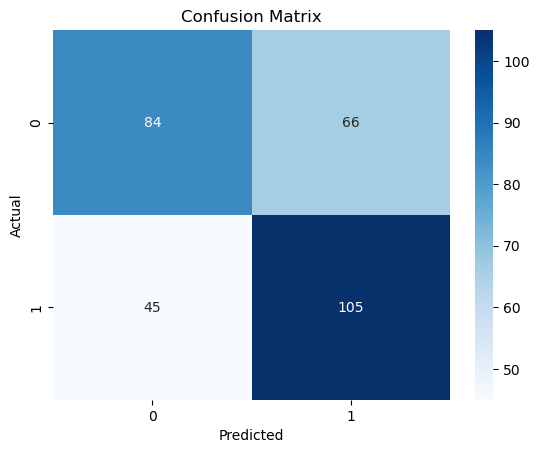

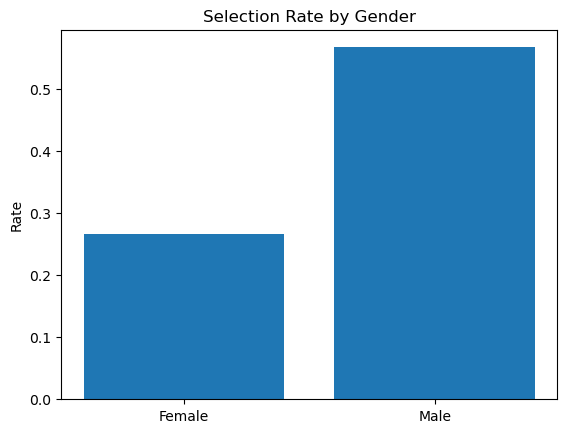

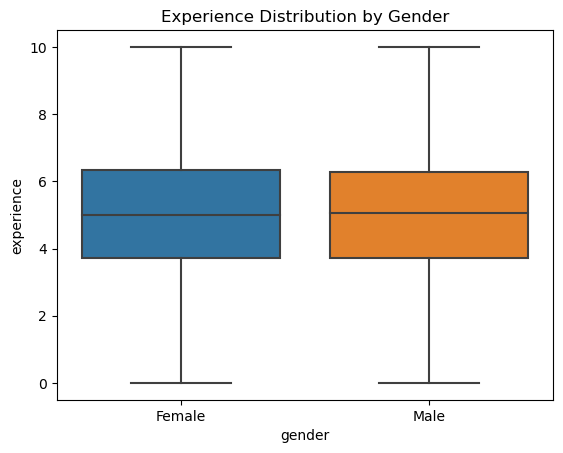

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test_full, y_pred_full)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Selection rate by gender
plt.bar(['Female', 'Male'], metrics.by_group['selection_rate'])
plt.title('Selection Rate by Gender')
plt.ylabel('Rate')
plt.show()

# Distribution of experience by gender
sns.boxplot(x='gender', y='experience', data=data)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Experience Distribution by Gender')
plt.show()

In [58]:
from sklearn.model_selection import cross_val_score

model_full = LogisticRegression(max_iter=200)
model_full_score = cross_val_score(model_full, X_full, y_full, cv=5, scoring='accuracy')
model_full_score
print("Cross-Validation Scores for Logistic Regression:", model_full_score
)


Cross-Validation Scores for Logistic Regression: [0.625 0.61  0.685 0.67  0.66 ]


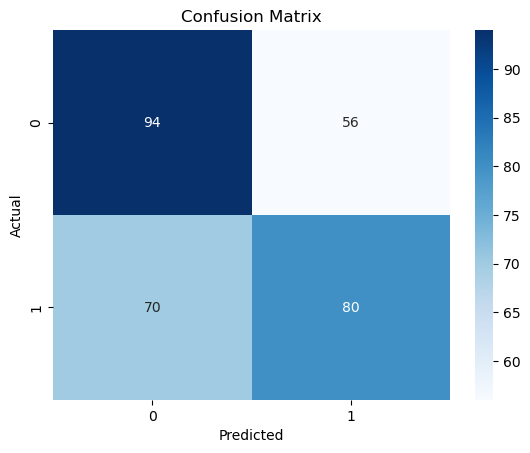

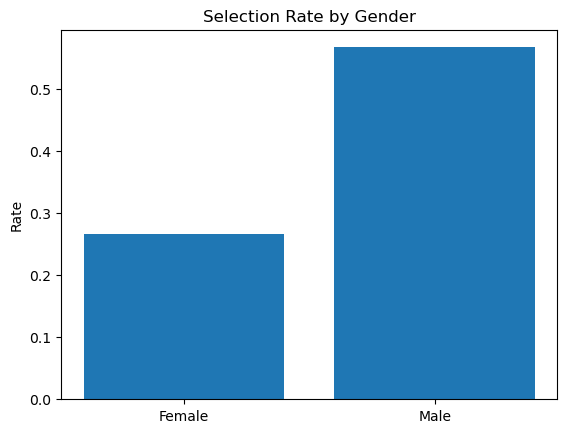

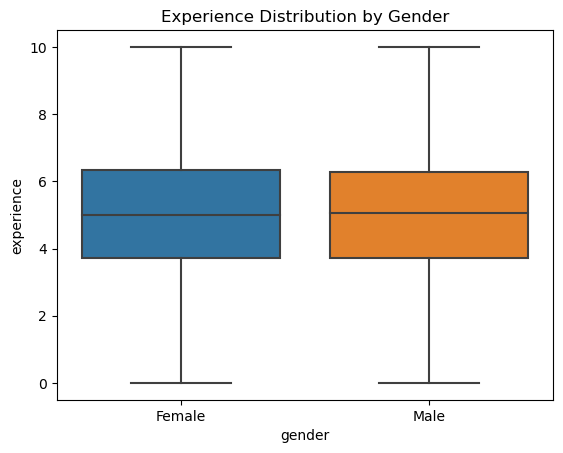

In [27]:
# Confusion matrix
cm = confusion_matrix(y_test_full2, y_pred_full2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Selection rate by gender
plt.bar(['Female', 'Male'], metrics.by_group['selection_rate'])
plt.title('Selection Rate by Gender')
plt.ylabel('Rate')
plt.show()

# Distribution of experience by gender
sns.boxplot(x='gender', y='experience', data=data)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Experience Distribution by Gender')
plt.show()

In [62]:
model2_full = RandomForestClassifier(n_estimators=200, random_state=42)

model2_full_score = cross_val_score(model2_full, X_full2, y_full, cv=5)
model2_full_score
print("Cross-Validation Scores for Random forest:", model2_full_score)


Cross-Validation Scores for Random forest: [0.5   0.605 0.635 0.59  0.555]
